# `Social Media Users Survey: Behavioral Dependence Analysis`

### Introduction

> This notebook explores a social media user survey dataset containing demographic information, daily usage time, distraction, validation-seeking, social comparison, mood, and sleep-related responses.  
> The goal is to analyze how daily social media use and self-reported behavioral signals relate to potential social media dependence.

This notebook is designed to run **locally** using the file:

```python
data/social_media_users.csv
```

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from pathlib import Path
import warnings

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Better notebook display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

warnings.filterwarnings("ignore")

In [2]:
# Read the dataset from the local data folder
DATA_PATH = Path("data") / "social_media_users.csv"
df = pd.read_csv(DATA_PATH)

# Display the first few rows
df.head(5)

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,2,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,5,4,4,5,5,3,3,3,4,4,1


> ### `Data Overview and Summary Statistics`

In [3]:
# Dataset information
print("\nDataset information:")
df.info()

# Summary statistics
print("\nSummary statistics of numerical variables:")
df.describe()


Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   Timestamp                                                                                                             481 non-null    str    
 1   1. What is your age?                                                                                                  481 non-null    float64
 2   2. Gender                                                                                                             481 non-null    str    
 3   3. Relationship Status                                                                                                481 non-null    str    
 4

,1. What is your age?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
count,481.00000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000
mean,26.13659,3.553015,3.320166,2.588358,3.349272,3.559252,3.245322,2.831601,2.775468,2.455301,3.255717,3.170478,3.201663
std,9.91511,1.096299,1.328137,1.257059,1.175552,1.283356,1.347105,1.407835,1.056479,1.247739,1.313033,1.256666,1.461619
min,13.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,21.00000,3.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000
50%,22.00000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000
75%,26.00000,4.000000,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,5.000000
max,91.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


>### `Data Pre-processing and Feature Engineering`

In [4]:
# Rename columns to shorter analysis-friendly names
df = df.rename(columns={
    "1. What is your age?": "Age",
    "2. Gender": "Gender",
    "3. Relationship Status": "Relationship_Status",
    "4. Occupation Status": "Occupation_Status",
    "5. What type of organizations are you affiliated with?": "Organization_Type",
    "6. Do you use social media?": "Uses_Social_Media",
    "7. What social media platforms do you commonly use?": "Platforms_Used",
    "8. What is the average time you spend on social media every day?": "Daily_Usage_Time",
    "9. How often do you find yourself using Social media without a specific purpose?": "Mindless_Use",
    "10. How often do you get distracted by Social media when you are busy doing something?": "Distraction_When_Busy",
    "11. Do you feel restless if you haven't used Social media in a while?": "Restless_Without_SM",
    "12. On a scale of 1 to 5, how easily distracted are you?": "Distractibility_Score",
    "13. On a scale of 1 to 5, how much are you bothered by worries?": "Worry_Score",
    "14. Do you find it difficult to concentrate on things?": "Concentration_Difficulty",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?": "Social_Comparison",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?": "Comparison_Feeling",
    "17. How often do you look to seek validation from features of social media?": "Validation_Seeking",
    "18. How often do you feel depressed or down?": "Depression_Frequency",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?": "Interest_Fluctuation",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?": "Sleep_Issues"
})

# Drop timestamp because it is not useful for behavioral analysis
df = df.drop(columns=["Timestamp"])

df.head()

,Age,Gender,Relationship_Status,Occupation_Status,Organization_Type,Uses_Social_Media,Platforms_Used,Daily_Usage_Time,Mindless_Use,Distraction_When_Busy,Restless_Without_SM,Distractibility_Score,Worry_Score,Concentration_Difficulty,Social_Comparison,Comparison_Feeling,Validation_Seeking,Depression_Frequency,Interest_Fluctuation,Sleep_Issues
0,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5
1,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5
2,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5
3,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,2,1,3,5,3,5,1,2,4,3,2
4,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,5,4,4,5,5,3,3,3,4,4,1


In [5]:
# Check missing values
print("Missing values by column:")
print(df.isnull().sum())

# Check unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts().head(20))

Missing values by column:
Age                          0
Gender                       0
Relationship_Status          0
Occupation_Status            0
Organization_Type           30
Uses_Social_Media            0
Platforms_Used               0
Daily_Usage_Time             0
Mindless_Use                 0
Distraction_When_Busy        0
Restless_Without_SM          0
Distractibility_Score        0
Worry_Score                  0
Concentration_Difficulty     0
Social_Comparison            0
Comparison_Feeling           0
Validation_Seeking           0
Depression_Frequency         0
Interest_Fluctuation         0
Sleep_Issues                 0
dtype: int64

Unique values in Gender:
Gender
Female                 263
Male                   211
Nonbinary                1
Non-binary               1
NB                       1
unsure                   1
Trans                    1
Non binary               1
There are others???      1
Name: count, dtype: int64

Unique values in Relationship_Status:


>### `Create additional features for analysis`

In [6]:
# Clean inconsistent gender labels
gender_map = {
    "Male": "Male",
    "Female": "Female",
    "Nonbinary": "Other",
    "Non-binary": "Other",
    "NB": "Other",
    "unsure": "Other",
    "Trans": "Other",
    "Non binary": "Other",
    "There are others???": "Other"
}
df["Gender_Clean"] = df["Gender"].map(gender_map).fillna("Other")

# Convert daily usage text to approximate numeric hours
usage_map = {
    "Less than an Hour": 0.5,
    "Between 1 and 2 hours": 1.5,
    "Between 2 and 3 hours": 2.5,
    "Between 3 and 4 hours": 3.5,
    "Between 4 and 5 hours": 4.5,
    "More than 5 hours": 6.0
}
df["Daily_Usage_Hours"] = df["Daily_Usage_Time"].map(usage_map)

# Create age groups
age_bins = [0, 18, 25, 35, 50, 100]
age_labels = ["<18", "18-24", "25-34", "35-49", "50+"]
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, right=False)

# Create usage categories
usage_bins = [0, 1, 3, 5, 10]
usage_labels = ["Light (<1h)", "Moderate (1-3h)", "High (3-5h)", "Very High (5h+)"]
df["Usage_Category"] = pd.cut(df["Daily_Usage_Hours"], bins=usage_bins, labels=usage_labels, right=False)

# Count how many platforms are listed
df["Platform_Count"] = df["Platforms_Used"].fillna("").apply(
    lambda x: len([p.strip() for p in str(x).split(",") if p.strip()])
)

# Convert survey response columns to numeric
behavior_cols = [
    "Mindless_Use",
    "Distraction_When_Busy",
    "Restless_Without_SM",
    "Distractibility_Score",
    "Worry_Score",
    "Concentration_Difficulty",
    "Social_Comparison",
    "Comparison_Feeling",
    "Validation_Seeking",
    "Depression_Frequency",
    "Interest_Fluctuation",
    "Sleep_Issues"
]
for col in behavior_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create an overall behavioral dependence score
df["Behavioral_Dependence_Score"] = df[behavior_cols].mean(axis=1)

# Create a 3-level dependence risk category
def classify_dependence(score):
    if score < 2.5:
        return "Low"
    elif score < 3.5:
        return "Moderate"
    return "High"

df["Dependence_Risk"] = df["Behavioral_Dependence_Score"].apply(classify_dependence)

df.head()

,Age,Gender,Relationship_Status,Occupation_Status,Organization_Type,Uses_Social_Media,Platforms_Used,Daily_Usage_Time,Mindless_Use,Distraction_When_Busy,Restless_Without_SM,Distractibility_Score,Worry_Score,Concentration_Difficulty,Social_Comparison,Comparison_Feeling,Validation_Seeking,Depression_Frequency,Interest_Fluctuation,Sleep_Issues,Gender_Clean,Daily_Usage_Hours,Age_Group,Usage_Category,Platform_Count,Behavioral_Dependence_Score,Dependence_Risk
0,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5,Male,2.5,18-24,Moderate (1-3h),6,3.583333,High
1,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5,Female,6.0,18-24,Very High (5h+),6,3.583333,High
2,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5,Female,3.5,18-24,High (3-5h),4,2.916667,Moderate
3,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,2,1,3,5,3,5,1,2,4,3,2,Female,6.0,18-24,Very High (5h+),2,2.916667,Moderate
4,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,5,4,4,5,5,3,3,3,4,4,1,Female,2.5,18-24,Moderate (1-3h),3,3.666667,High


## 1. `Exploratory Data Analysis (EDA)`

>### 1. User Demographics

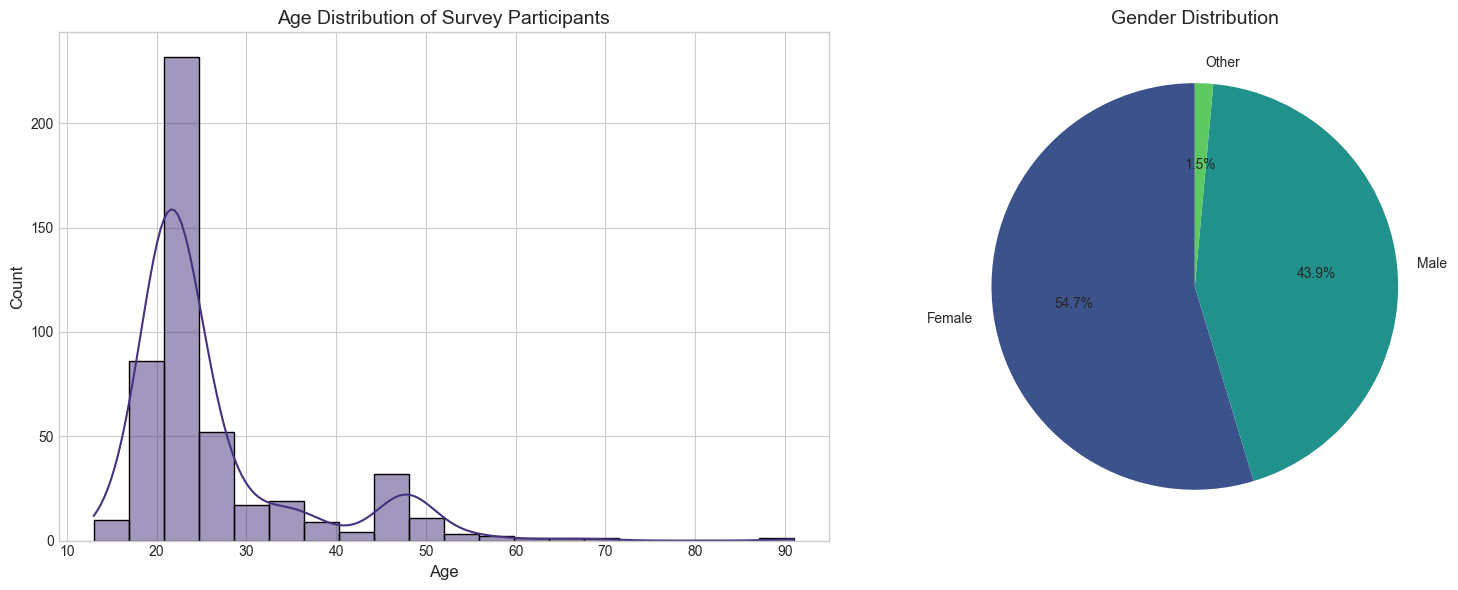

In [7]:
plt.figure(figsize=(16, 6))

# Age distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True, bins=20)
plt.title('Age Distribution of Survey Participants', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Gender distribution
plt.subplot(1, 2, 2)
gender_counts = df['Gender_Clean'].value_counts()
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('viridis', len(gender_counts))
)
plt.title('Gender Distribution', fontsize=14)

plt.tight_layout()
plt.show()

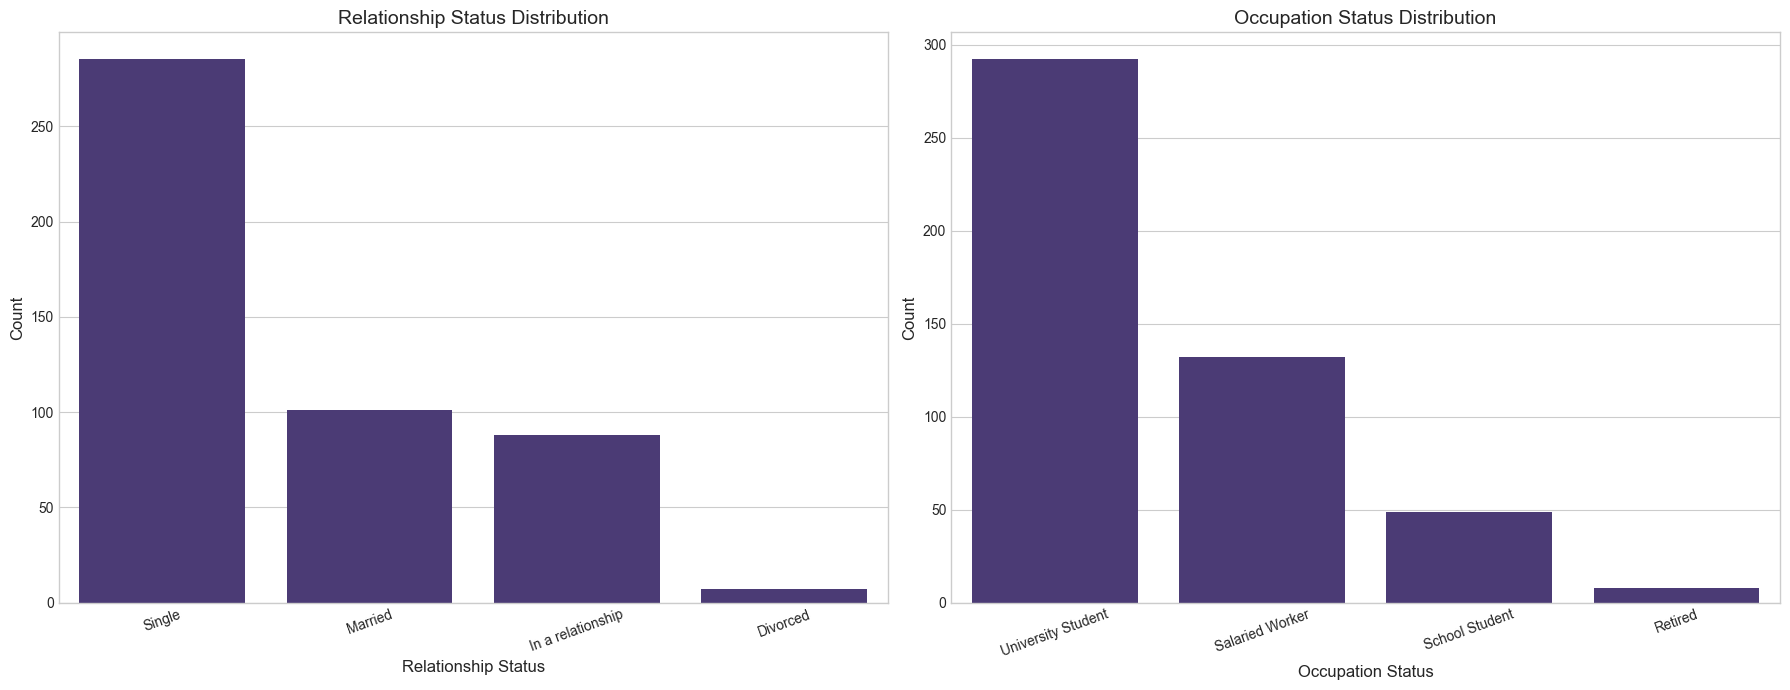

In [8]:
plt.figure(figsize=(18, 7))

# Relationship status distribution
plt.subplot(1, 2, 1)
relationship_counts = df['Relationship_Status'].value_counts()
sns.barplot(x=relationship_counts.index, y=relationship_counts.values)
plt.title('Relationship Status Distribution', fontsize=14)
plt.xlabel('Relationship Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=20)

# Occupation status distribution
plt.subplot(1, 2, 2)
occupation_counts = df['Occupation_Status'].value_counts()
sns.barplot(x=occupation_counts.index, y=occupation_counts.values)
plt.title('Occupation Status Distribution', fontsize=14)
plt.xlabel('Occupation Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

>## `2. Social Media Usage Patterns`

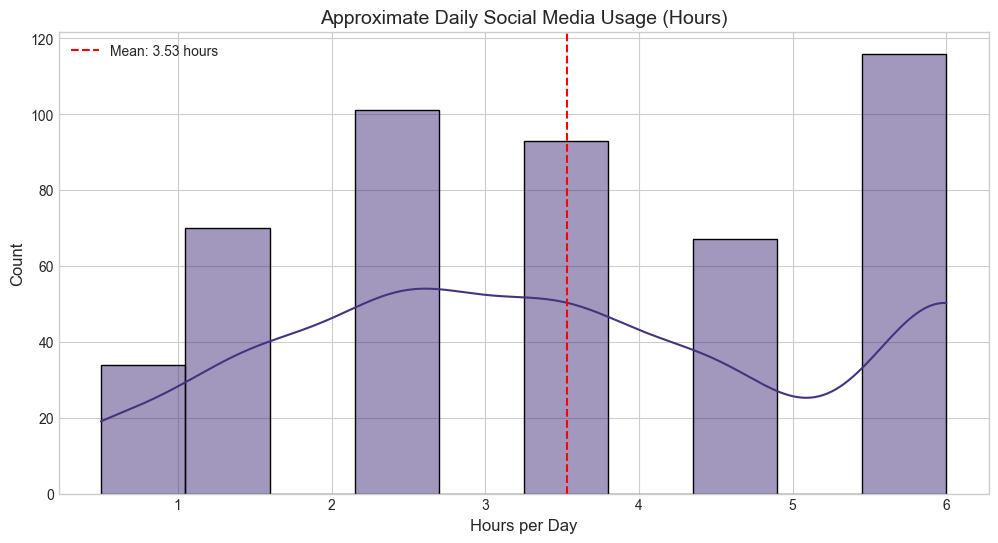

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Daily_Usage_Hours'], kde=True, bins=10)
mean_usage = df['Daily_Usage_Hours'].mean()
plt.title('Approximate Daily Social Media Usage (Hours)', fontsize=14)
plt.xlabel('Hours per Day', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(mean_usage, color='red', linestyle='--', label=f'Mean: {mean_usage:.2f} hours')
plt.legend()
plt.show()

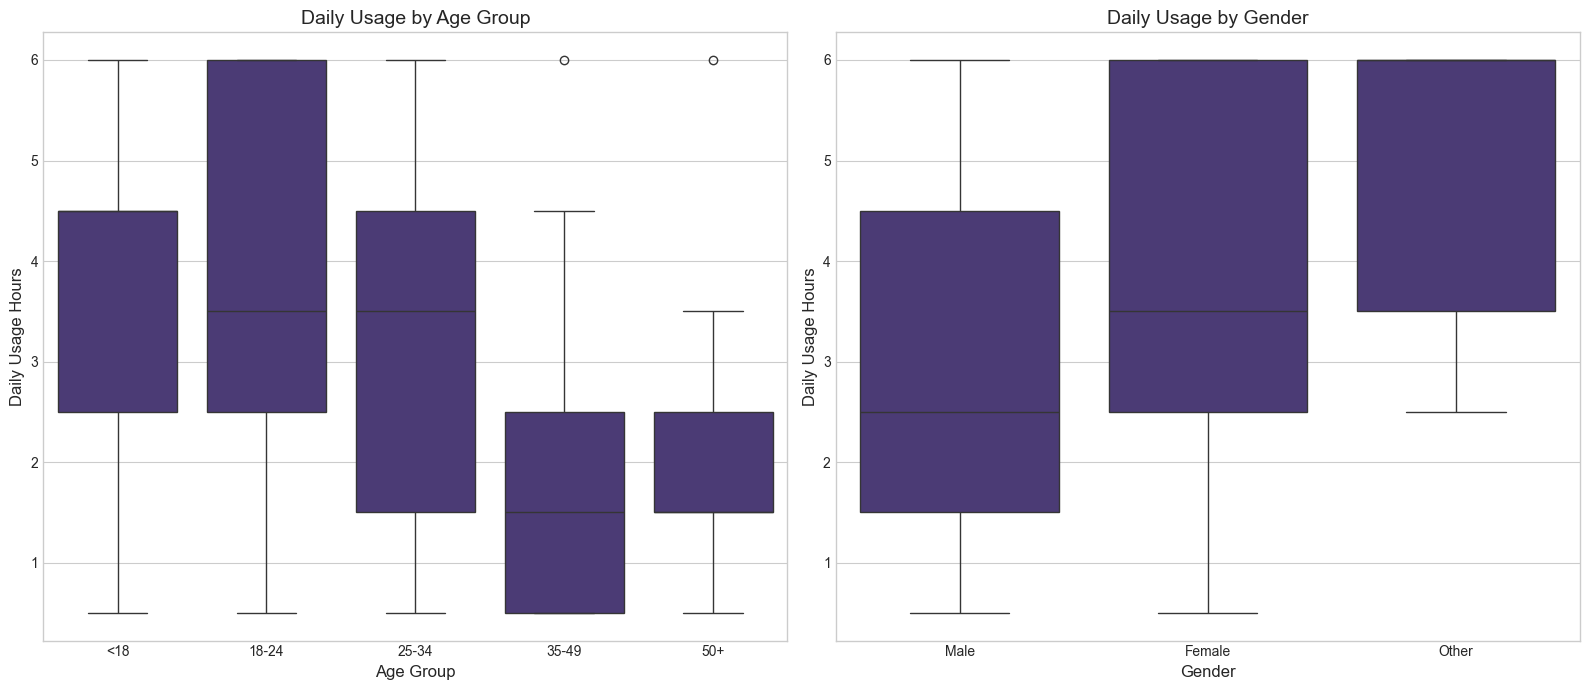

In [10]:
plt.figure(figsize=(16, 7))

# Usage by age group
plt.subplot(1, 2, 1)
sns.boxplot(x='Age_Group', y='Daily_Usage_Hours', data=df)
plt.title('Daily Usage by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Daily Usage Hours', fontsize=12)

# Usage by gender
plt.subplot(1, 2, 2)
sns.boxplot(x='Gender_Clean', y='Daily_Usage_Hours', data=df)
plt.title('Daily Usage by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Daily Usage Hours', fontsize=12)

plt.tight_layout()
plt.show()

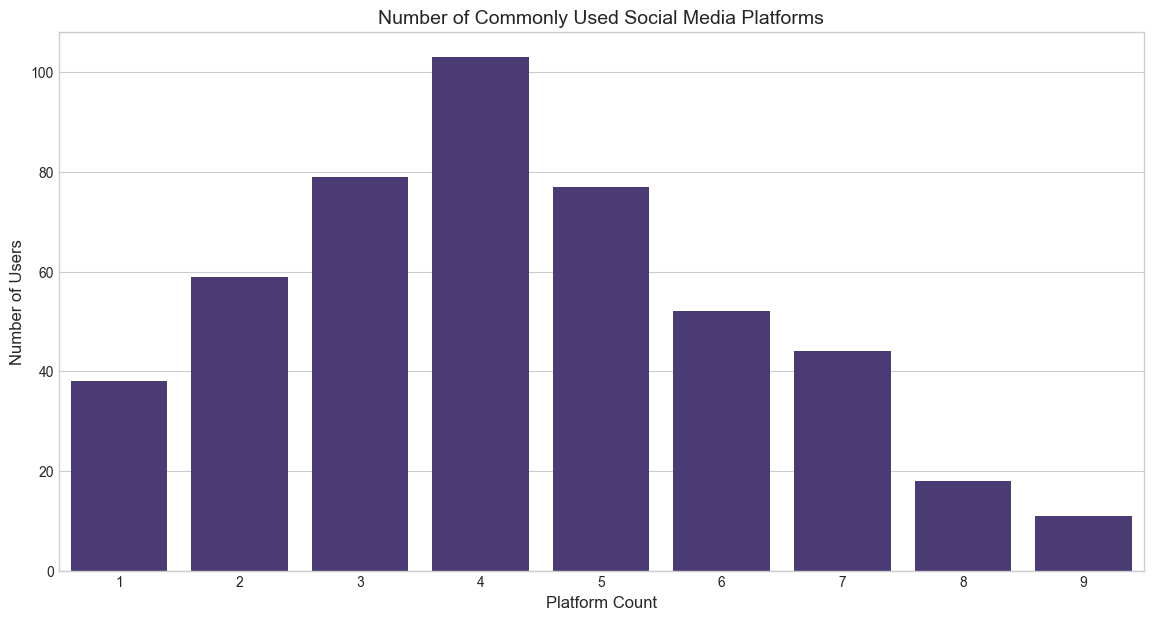

In [11]:
plt.figure(figsize=(14, 7))
platform_counts = df['Platform_Count'].value_counts().sort_index()
sns.barplot(x=platform_counts.index, y=platform_counts.values)
plt.title('Number of Commonly Used Social Media Platforms', fontsize=14)
plt.xlabel('Platform Count', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.show()

>## `3. Behavioral Dependence Indicators`

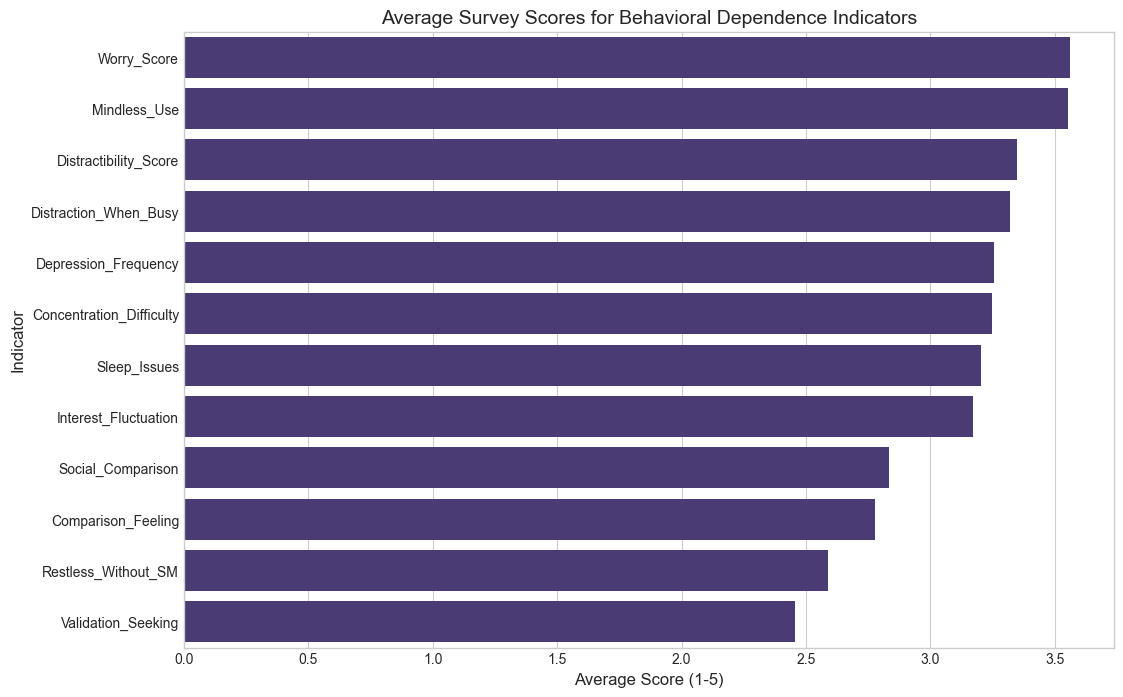

In [12]:
indicator_means = df[behavior_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=indicator_means.values, y=indicator_means.index)
plt.title('Average Survey Scores for Behavioral Dependence Indicators', fontsize=14)
plt.xlabel('Average Score (1-5)', fontsize=12)
plt.ylabel('Indicator', fontsize=12)
plt.show()

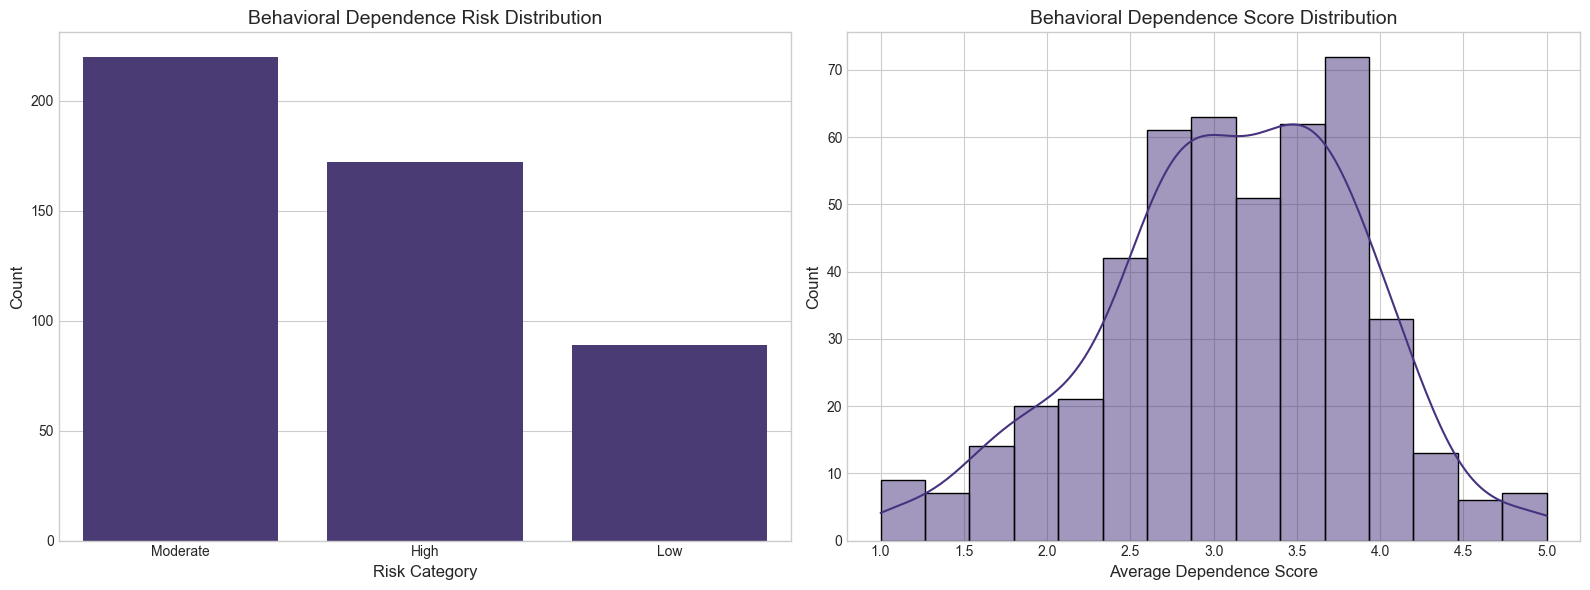

In [13]:
plt.figure(figsize=(16, 6))

# Dependence risk distribution
plt.subplot(1, 2, 1)
risk_counts = df['Dependence_Risk'].value_counts()
sns.barplot(x=risk_counts.index, y=risk_counts.values)
plt.title('Behavioral Dependence Risk Distribution', fontsize=14)
plt.xlabel('Risk Category', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Dependence score distribution
plt.subplot(1, 2, 2)
sns.histplot(df['Behavioral_Dependence_Score'], kde=True, bins=15)
plt.title('Behavioral Dependence Score Distribution', fontsize=14)
plt.xlabel('Average Dependence Score', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

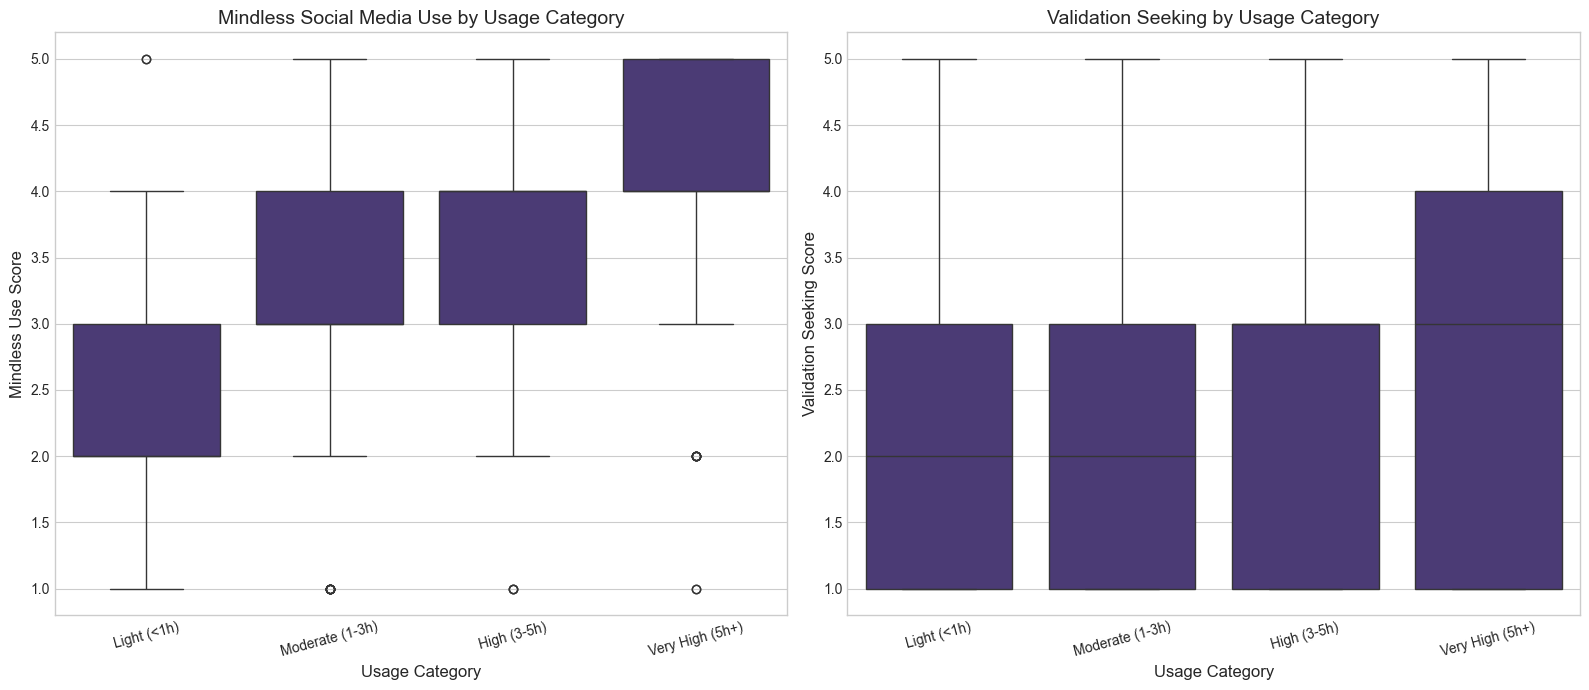

In [14]:
plt.figure(figsize=(16, 7))

# Mindless use by daily usage category
plt.subplot(1, 2, 1)
sns.boxplot(x='Usage_Category', y='Mindless_Use', data=df)
plt.title('Mindless Social Media Use by Usage Category', fontsize=14)
plt.xlabel('Usage Category', fontsize=12)
plt.ylabel('Mindless Use Score', fontsize=12)
plt.xticks(rotation=15)

# Validation seeking by usage category
plt.subplot(1, 2, 2)
sns.boxplot(x='Usage_Category', y='Validation_Seeking', data=df)
plt.title('Validation Seeking by Usage Category', fontsize=14)
plt.xlabel('Usage Category', fontsize=12)
plt.ylabel('Validation Seeking Score', fontsize=12)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

>## `4. Mood, Sleep, and Concentration Analysis`

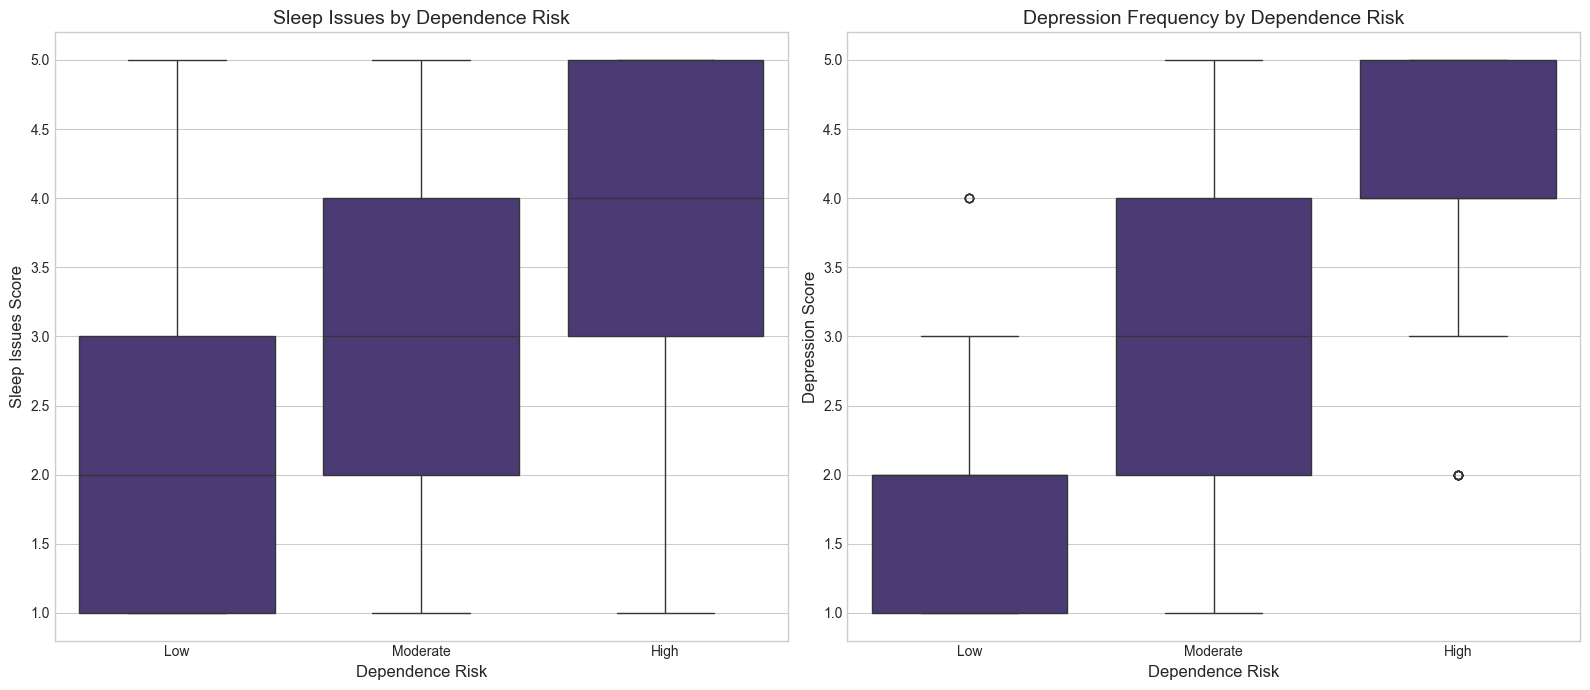

In [15]:
plt.figure(figsize=(16, 7))

# Sleep issues by dependence risk
plt.subplot(1, 2, 1)
sns.boxplot(x='Dependence_Risk', y='Sleep_Issues', data=df, order=['Low', 'Moderate', 'High'])
plt.title('Sleep Issues by Dependence Risk', fontsize=14)
plt.xlabel('Dependence Risk', fontsize=12)
plt.ylabel('Sleep Issues Score', fontsize=12)

# Depression by dependence risk
plt.subplot(1, 2, 2)
sns.boxplot(x='Dependence_Risk', y='Depression_Frequency', data=df, order=['Low', 'Moderate', 'High'])
plt.title('Depression Frequency by Dependence Risk', fontsize=14)
plt.xlabel('Dependence Risk', fontsize=12)
plt.ylabel('Depression Score', fontsize=12)

plt.tight_layout()
plt.show()

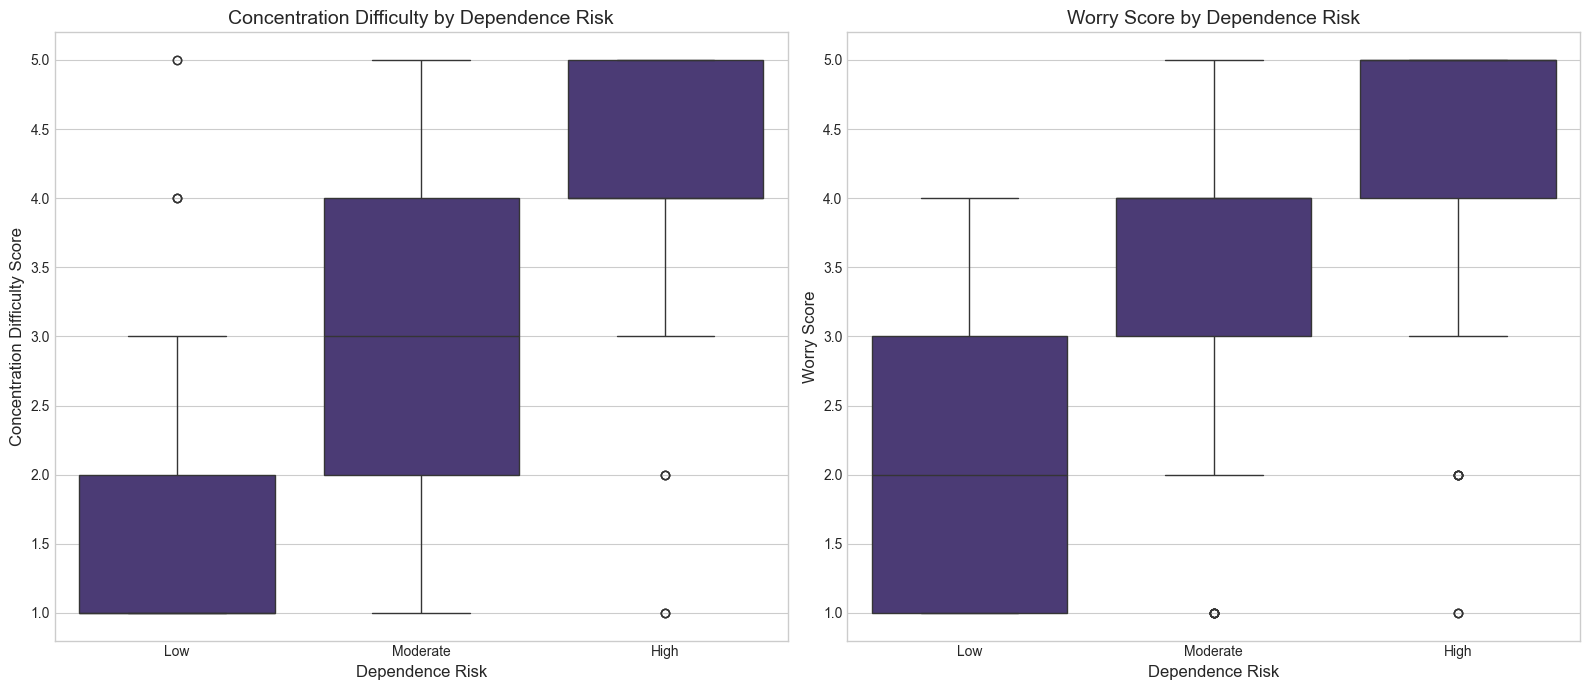

In [16]:
plt.figure(figsize=(16, 7))

# Concentration difficulty by dependence risk
plt.subplot(1, 2, 1)
sns.boxplot(x='Dependence_Risk', y='Concentration_Difficulty', data=df, order=['Low', 'Moderate', 'High'])
plt.title('Concentration Difficulty by Dependence Risk', fontsize=14)
plt.xlabel('Dependence Risk', fontsize=12)
plt.ylabel('Concentration Difficulty Score', fontsize=12)

# Worry score by dependence risk
plt.subplot(1, 2, 2)
sns.boxplot(x='Dependence_Risk', y='Worry_Score', data=df, order=['Low', 'Moderate', 'High'])
plt.title('Worry Score by Dependence Risk', fontsize=14)
plt.xlabel('Dependence Risk', fontsize=12)
plt.ylabel('Worry Score', fontsize=12)

plt.tight_layout()
plt.show()

>## `5. Relationship Status and Social Comparison Analysis`

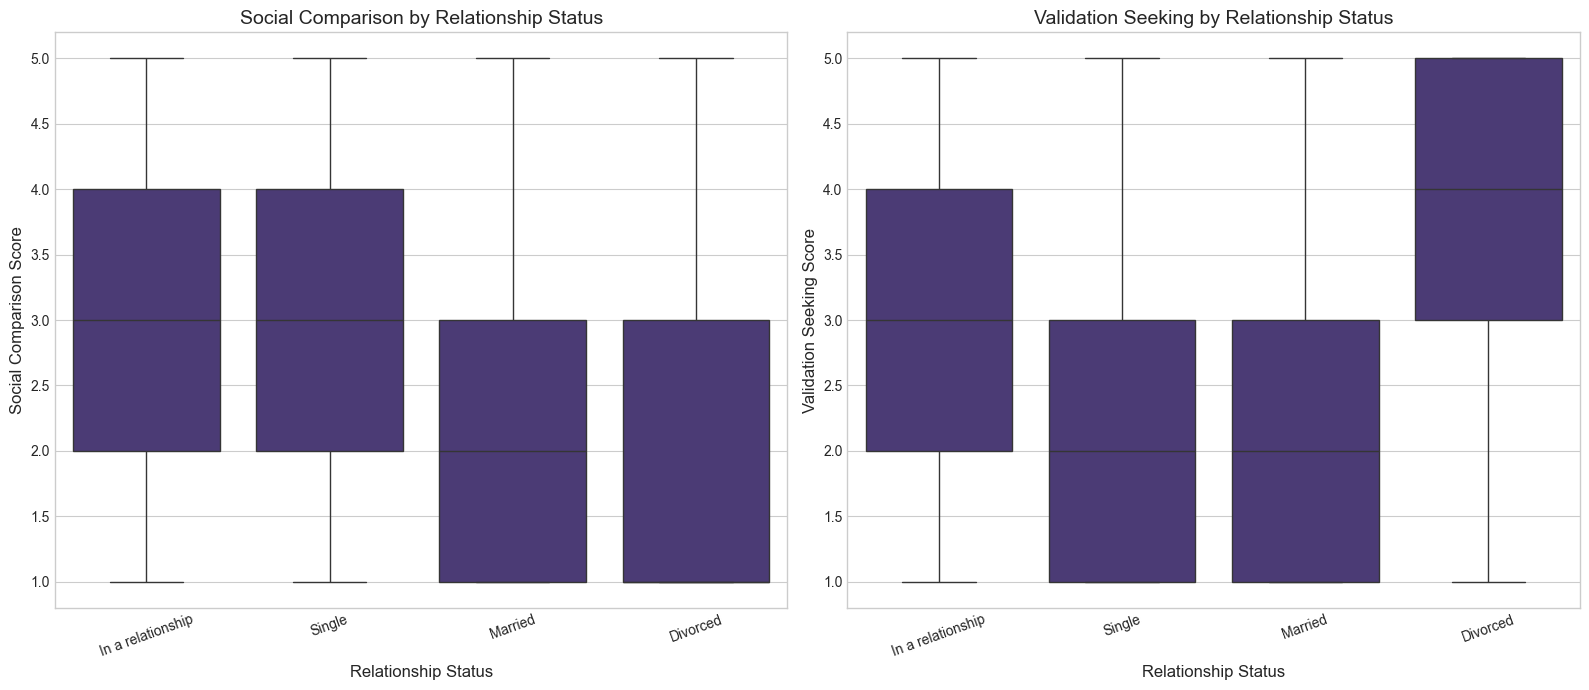

In [17]:
plt.figure(figsize=(16, 7))

# Social comparison by relationship status
plt.subplot(1, 2, 1)
sns.boxplot(x='Relationship_Status', y='Social_Comparison', data=df)
plt.title('Social Comparison by Relationship Status', fontsize=14)
plt.xlabel('Relationship Status', fontsize=12)
plt.ylabel('Social Comparison Score', fontsize=12)
plt.xticks(rotation=20)

# Validation seeking by relationship status
plt.subplot(1, 2, 2)
sns.boxplot(x='Relationship_Status', y='Validation_Seeking', data=df)
plt.title('Validation Seeking by Relationship Status', fontsize=14)
plt.xlabel('Relationship Status', fontsize=12)
plt.ylabel('Validation Seeking Score', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

>## `6. Correlation and Statistical Analysis`

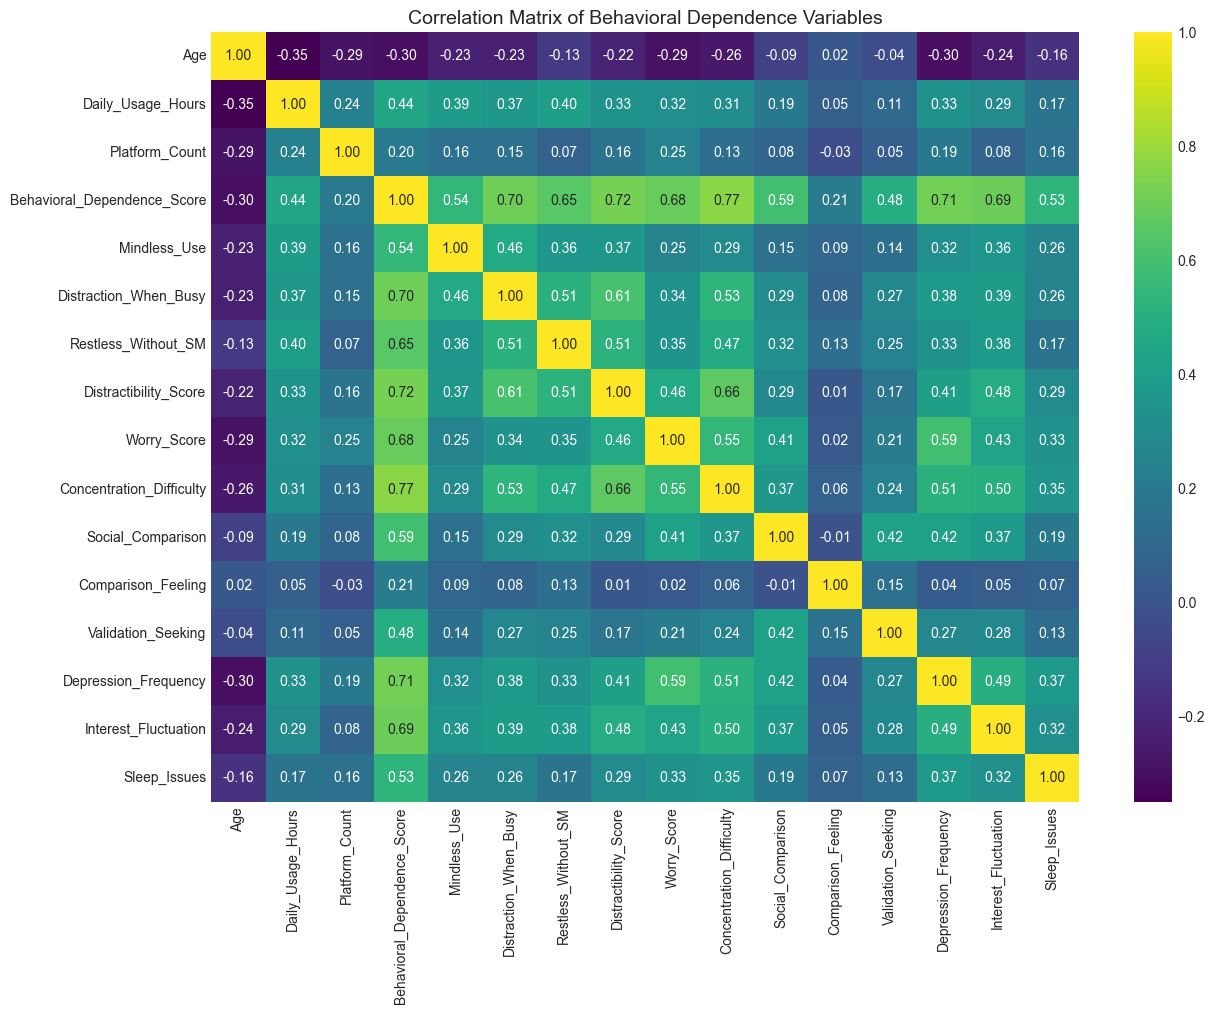

In [18]:
# Create a numeric dataframe for correlation analysis
numeric_cols = ['Age', 'Daily_Usage_Hours', 'Platform_Count', 'Behavioral_Dependence_Score'] + behavior_cols
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Behavioral Dependence Variables', fontsize=14)
plt.show()

In [19]:
# Strongest correlations with dependence score
dependence_corr = corr['Behavioral_Dependence_Score'].sort_values(ascending=False)
print("Correlations with Behavioral_Dependence_Score:")
print(dependence_corr)

Correlations with Behavioral_Dependence_Score:
Behavioral_Dependence_Score    1.000000
Concentration_Difficulty       0.765458
Distractibility_Score          0.719489
Depression_Frequency           0.710761
Distraction_When_Busy          0.700077
Interest_Fluctuation           0.694949
Worry_Score                    0.684645
Restless_Without_SM            0.650968
Social_Comparison              0.593182
Mindless_Use                   0.539368
Sleep_Issues                   0.528832
Validation_Seeking             0.483989
Daily_Usage_Hours              0.443500
Comparison_Feeling             0.206874
Platform_Count                 0.201812
Age                           -0.300130
Name: Behavioral_Dependence_Score, dtype: float64


In [20]:
# One-way ANOVA: does daily usage differ by dependence risk group?
low_group = df[df['Dependence_Risk'] == 'Low']['Daily_Usage_Hours']
moderate_group = df[df['Dependence_Risk'] == 'Moderate']['Daily_Usage_Hours']
high_group = df[df['Dependence_Risk'] == 'High']['Daily_Usage_Hours']

f_stat, p_val = stats.f_oneway(low_group, moderate_group, high_group)
print(f"ANOVA for Daily Usage Hours across Dependence Risk groups: F = {f_stat:.4f}, p = {p_val:.6f}")

ANOVA for Daily Usage Hours across Dependence Risk groups: F = 52.3146, p = 0.000000


>## `7. Interactive Visualizations with Plotly`

In [21]:
fig = px.scatter(
    df,
    x='Daily_Usage_Hours',
    y='Behavioral_Dependence_Score',
    color='Dependence_Risk',
    size='Platform_Count',
    hover_data=['Age', 'Gender_Clean', 'Relationship_Status'],
    title='Daily Usage vs Behavioral Dependence Score'
)
fig.show()

In [22]:
fig = px.box(
    df,
    x='Usage_Category',
    y='Sleep_Issues',
    color='Usage_Category',
    title='Sleep Issues by Daily Usage Category'
)
fig.show()

In [23]:
fig = px.violin(
    df,
    x='Dependence_Risk',
    y='Depression_Frequency',
    color='Dependence_Risk',
    box=True,
    points='all',
    title='Depression Frequency by Dependence Risk'
)
fig.show()

### `Key Insights from the Analysis:`

#### 1. Usage Patterns and Demographics
- The dataset captures a wide age range, but many respondents are young adults.
- Daily social media usage spans from **less than 1 hour** to **more than 5 hours**, with many users clustered in the moderate to heavy-use categories.
- Users often report using multiple social media platforms rather than only one.

#### 2. Behavioral Dependence Indicators
- Scores for distraction, mindless use, restlessness, validation seeking, and sleep issues can be combined into a practical **behavioral dependence score**.
- This derived score creates a useful **Low / Moderate / High** dependence-risk grouping even though the dataset does not include a direct addiction label.

#### 3. Mood and Functional Impact
- Higher dependence-risk groups tend to report more **sleep issues**, **depressed mood**, **worry**, and **difficulty concentrating**.
- These results suggest that heavier or more compulsive social media use may be associated with broader mental well-being concerns.

#### 4. Social Comparison and Validation
- Social comparison and validation-seeking are valuable features in this dataset because they capture the emotional and psychological side of social media use.
- These variables can be useful for a later recommendation stage even if they are not the strongest predictors in a simple model.

#### 5. Project Usefulness
- This dataset is especially useful for:
  - **behavioral feature engineering**
  - **survey-based dependence scoring**
  - **follow-up question design**
  - **LLM / RAG recommendation prompts**